In [58]:
import os
import glob

import numpy as np
import scipy.stats as stats
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import json

from pathlib import Path
home = str(Path.home())

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams.update({'font.size': 10})

colorsCustom = ['#8dd3c7','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69']

plotFolder = home+"/research_ua/icecube/Upgrade/timing_calibration/plots/mdom_transit"
domcal_data = "/Users/epaudel/Library/CloudStorage/OneDrive-TheUniversityofAlabama/research_notes/notes/vetted_domcal/vetted domcal JSON/"
# domcal_data = "/Users/epaudel/Library/CloudStorage/OneDrive-TheUniversityofAlabama/research_notes/notes/vetted_domcal/vetted domcal JSON/0a00000f17ae622d_degg.json"

mdom_domcal_files = sorted(glob.glob(domcal_data+"/*_mdom.json"))

In [59]:
mdom_list = [f.path for f in os.scandir(home+"/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/") if f.is_dir()][:]
mdom_list_desy = []
mdom_list_desy_dvt = []
mdom_list_msu = []
for ifile in mdom_list:
    if ifile.split("/")[-1].split("_")[1][0]=="M":
        mdom_list_msu.append(ifile)
    elif "DVT" in ifile.split("/")[-1].split("_")[1]:
        mdom_list_desy_dvt.append(ifile)
    else:
        mdom_list_desy.append(ifile)


mdom_names = [istr.split("/")[-1] for istr in mdom_list]


upgrade_commissioning_scripts = home+"/research_ua/icecube/software/upgrade_commissioning_scripts/"

geometry_files = sorted(glob.glob(upgrade_commissioning_scripts+"/geometry/string_*geometry*.json"))


string_list = ["88","89","90","91","92"]

In [84]:
from parse_vetted_domcal import get_nominal_hv_prod_id, fat_vs_ice_hv_scatter,get_device_list,get_mdom_production_id,get_fat_transit_time

In [61]:
transit_times_single_gaussian_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_gaussian_refit.json"


In [62]:
def get_fat_hv(fat_tt_file,prod_id,channel):
    '''
    get transit time for a given production id and channel
    '''
    hv_value = np.nan    
    with open(fat_tt_file, 'r') as f:
        data = json.load(f)
        for mdom, tt_data in data.items():
            if str(mdom) in [str(prod_id)]:
                print(f"Checking mdom: {mdom}, prod_id: {prod_id} {tt_data["transit_times"].keys()}")
                available_channels =   [k.split('_')[1] for k in tt_data["transit_times"].keys()]
                print(f"available channels {available_channels}") 
                if str(channel) in available_channels:
                    for itt in tt_data["transit_times"][f"channel_{channel}"]:
                        if len(itt) > 0 and not np.isnan(itt["mu"]) and not np.isnan(itt["applied HV"]):
                            hv_value =  itt["applied HV"]
    return hv_value

In [63]:
deployed_device_list = get_device_list("88","mDOM") + get_device_list("89","mDOM") + get_device_list("90","mDOM") + get_device_list("91","mDOM") + get_device_list("92","mDOM")

combined_mdom_list = mdom_list_msu + mdom_list_desy
combined_mdom_list_deployed = [imdom for imdom in combined_mdom_list if get_mdom_production_id(imdom) in deployed_device_list]


In [ ]:
hv_fat_list = []
hv_ice_list = []
hv_diff_list = []
for imdom in mdom_list:
    prod_id = get_mdom_production_id(imdom)
    for ichannel in range(24):
        hv_ice = get_nominal_hv_prod_id(prod_id,ichannel)
        hv_fat = get_fat_hv(transit_times_single_gaussian_file,prod_id,ichannel)
        print(f"prod id {prod_id} channel {ichannel} hv fat {hv_fat} hv ice {hv_ice}")
        # if not np.isnan(hv_fat) and not np.isnan(hv_ice) and not abs(hv_fat-90)<0.5:
        if not np.isnan(hv_fat) and not np.isnan(hv_ice):
            hv_fat_list.append(hv_fat)
            hv_ice_list.append(hv_ice)
            hv_diff_list.append(hv_fat - hv_ice)

Checking mdom: mDOM_D129, prod_id: mDOM_D129 dict_keys(['channel_0', 'channel_1', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_6', 'channel_7', 'channel_8', 'channel_9', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_20', 'channel_21', 'channel_22', 'channel_23'])
available channels ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23']
prod id mDOM_D129 channel 0 hv fat 83.029999 hv ice 79.50164525282376
Checking mdom: mDOM_D129, prod_id: mDOM_D129 dict_keys(['channel_0', 'channel_1', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_6', 'channel_7', 'channel_8', 'channel_9', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_20', 'channel_21', 'channel_22', 'channel_23'])
available 

In [90]:
def fat_vs_ice_hv_scatter(mdom_list,transit_times_single_gaussian_file=transit_times_single_gaussian_file):
    fig = plt.figure(figsize=(8,5))
    gs = gridspec.GridSpec(nrows=1,ncols=1)
    ax = fig.add_subplot(gs[0])
    ax.scatter(hv_fat_list, hv_ice_list, color=colorsCustom[0], alpha=0.7, label='data')
    ax.plot([min(hv_fat_list), max(hv_fat_list)], [min(hv_fat_list), max(hv_fat_list)], color='red', linestyle='--', label='y=x')
    ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax.set_xlabel(r"$V_{FAT}$ [V]", fontsize=22)
    ax.set_ylabel(r"$V_{Ice}$ [V]", fontsize=22)
    ax.text(0.05, 0.95, fr"mean $V_{{{'FAT'}}}$: {np.mean(hv_fat_list):.0f}"+f" \u00B1"+fr" {np.std(hv_fat_list):.0f} V", transform=ax.transAxes, ha='left', va='top')
    ax.text(0.05, 0.85, fr"mean $V_{{{'Ice'}}}$: {np.mean(hv_ice_list):.0f}"+f" \u00B1"+fr" {np.std(hv_ice_list):.0f} V", transform=ax.transAxes, ha='left', va='top')
    ax.grid(True,alpha=0.6)
    ax.legend(fontsize=12,ncols=1)
    plt.savefig(plotFolder+f"/hv_fat_vs_hv_ice.png",transparent=False,bbox_inches='tight')
    plt.savefig(plotFolder+f"/hv_fat_vs_hv_ice.pdf",transparent=False,bbox_inches='tight')
    plt.show()

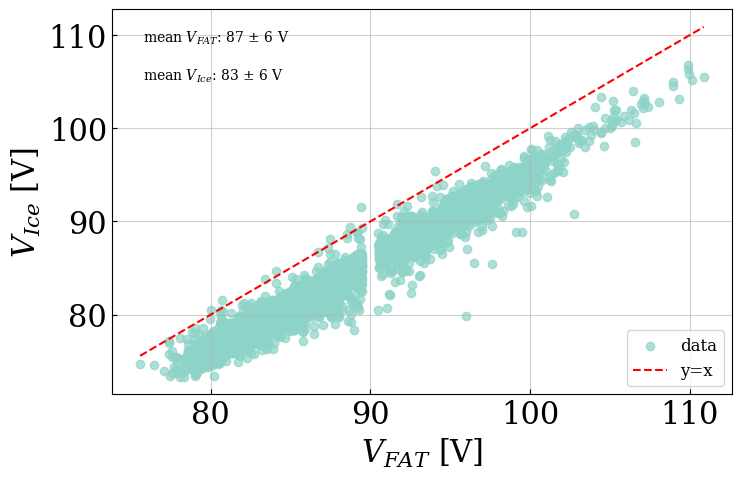

In [91]:
fat_vs_ice_hv_scatter(combined_mdom_list_deployed, transit_times_single_gaussian_file)

In [92]:
def fat_vs_ice_hv_diff(mdom_list,transit_times_single_gaussian_file=transit_times_single_gaussian_file):
    fig = plt.figure(figsize=(8,5))
    gs = gridspec.GridSpec(nrows=1,ncols=1)
    ax = fig.add_subplot(gs[0])
    ax.hist(hv_diff_list,histtype='step', bins=60,linewidth=3, color=colorsCustom[1], alpha=1, label='data')
    # ax.plot([min(hv_diff_list), max(hv_diff_list)], [min(hv_diff_list), max(hv_diff_list)], color='red', linestyle='--', label='y=x')
    ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax.set_xlabel(r"$V_{FAT}-V_{Ice}$ [V]", fontsize=22)
    ax.set_ylabel(r"PMT count", fontsize=22)
    ax.grid(True,alpha=0.6)
    ax.set_yscale('log')
    ax.legend(fontsize=12,ncols=1)
    plt.savefig(plotFolder+f"/hv_fat_vs_hv_ice_diff.png",transparent=False,bbox_inches='tight')
    plt.savefig(plotFolder+f"/hv_fat_vs_hv_ice_diff.pdf",transparent=False,bbox_inches='tight')
    plt.show()
    # plt.close()

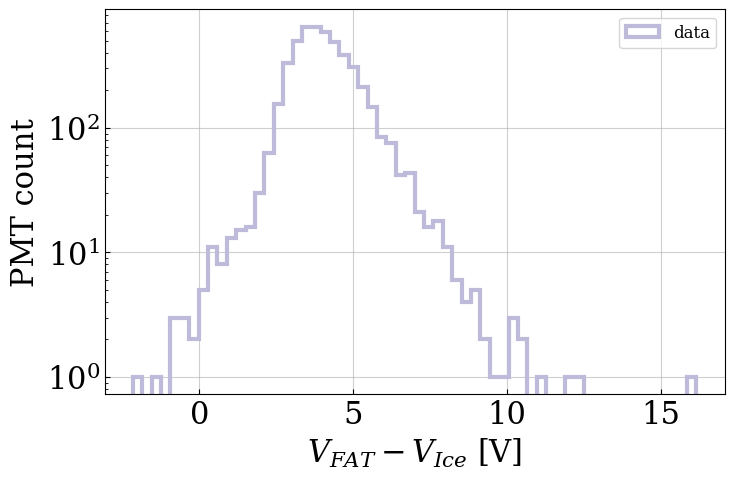

In [93]:
fat_vs_ice_hv_diff(combined_mdom_list_deployed, transit_times_single_gaussian_file)

In [81]:
def get_both_transit_time(prod_id,channel):
    '''
    get corrected transit time for a given production id and channel
    '''
    tt_fat, hv_fat = get_fat_transit_time(prod_id,channel)
    nominal_hv = get_nominal_hv_prod_id(prod_id,channel)
    tt_ice = tt_fat * (hv_fat/nominal_hv)**(0.5)
    return tt_fat,tt_ice

In [87]:
def transit_time_diff_hist(mdom_list):
    transit_times_diff = []

    for imdom in mdom_list:
        prod_id = get_mdom_production_id(imdom)
        for ichannel in range(24):
            tt_fat, hv_fat = get_fat_transit_time(prod_id,ichannel)
            nominal_hv = get_nominal_hv_prod_id(prod_id,ichannel)
            tt_ice = tt_fat * (hv_fat/nominal_hv)**(0.5)
            if not np.isnan(hv_fat) and not np.isnan(tt_fat) and not np.isnan(tt_ice) and 0<tt_fat<100:
                tt_diff = tt_ice - tt_fat
                transit_times_diff.append(tt_diff)
    fig = plt.figure(figsize=(8,5))
    gs = gridspec.GridSpec(nrows=1,ncols=1)
    ax = fig.add_subplot(gs[0])
    ax.hist(transit_times_diff, bins=200,histtype='step',color=colorsCustom[0],linewidth=1.5 ,label=f'diff', alpha=0.7)
    ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax.set_xlabel(fr"$tt_{{{'Ice'}}}$ - $tt_{{{'FAT'}}}$ [ns]", fontsize=22)
    ax.set_ylabel(r"count", fontsize=22)
    ax.set_yscale('log')
    ax.text(0.95, 0.95, fr"mean $tt_{{{'Ice'}}}$ - $tt_{{{'FAT'}}}$: {np.mean(transit_times_diff):.2f}"+f" \u00B1"+fr" {np.std(transit_times_diff):.2f} ns", transform=ax.transAxes, ha='right', va='top')
    ax.grid(True,alpha=0.6)
    ax.legend(fontsize=12,ncols=1)
    plt.savefig(plotFolder+f"/diff_transit_time.png",transparent=False,bbox_inches='tight')
    plt.savefig(plotFolder+f"/diff_transit_time.pdf",transparent=False,bbox_inches='tight')
    plt.show()
    # plt.close()

vetted domcal file /Users/epaudel/Library/CloudStorage/OneDrive-TheUniversityofAlabama/research_notes/notes/vetted_domcal/vetted domcal JSON/ea000030c307962d_mdom.json does not exist
vetted domcal file /Users/epaudel/Library/CloudStorage/OneDrive-TheUniversityofAlabama/research_notes/notes/vetted_domcal/vetted domcal JSON/ea000030c307962d_mdom.json does not exist
vetted domcal file /Users/epaudel/Library/CloudStorage/OneDrive-TheUniversityofAlabama/research_notes/notes/vetted_domcal/vetted domcal JSON/ea000030c307962d_mdom.json does not exist
vetted domcal file /Users/epaudel/Library/CloudStorage/OneDrive-TheUniversityofAlabama/research_notes/notes/vetted_domcal/vetted domcal JSON/ea000030c307962d_mdom.json does not exist
vetted domcal file /Users/epaudel/Library/CloudStorage/OneDrive-TheUniversityofAlabama/research_notes/notes/vetted_domcal/vetted domcal JSON/ea000030c307962d_mdom.json does not exist
vetted domcal file /Users/epaudel/Library/CloudStorage/OneDrive-TheUniversityofAlabam

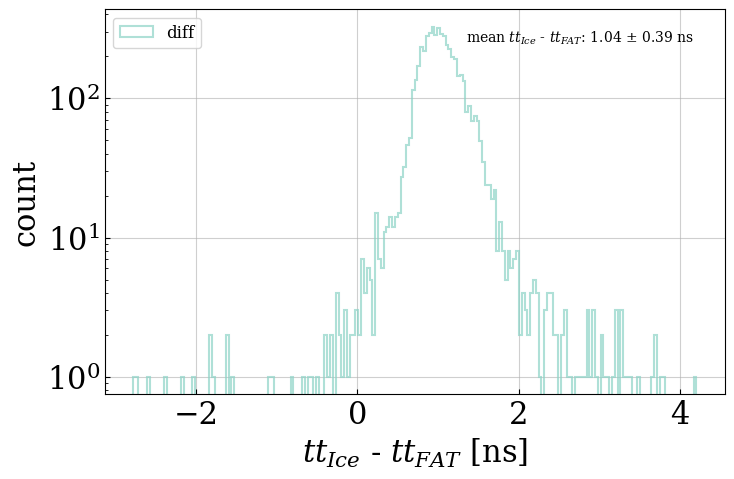

In [88]:
transit_time_diff_hist(combined_mdom_list_deployed)